In [1]:
# =============================================================================
# CELDA 1: Importaciones y Funciones (Incluye lógicas para Gaussianas)
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.lines import Line2D
import warnings

warnings.simplefilter('ignore')

# Configuración visual global
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 14, 'axes.labelsize': 14, 'axes.titlesize': 16, 
    'legend.fontsize': 12, 'figure.figsize': (10, 6),
    'lines.linewidth': 2, 'lines.markersize': 8, 'errorbar.capsize': 3
})

COLORS = {'Proton': 'royalblue', 'Helio': 'forestgreen', 'Oxigeno': 'purple', 'Hierro': 'firebrick', 'Mix': 'dimgray'}
MARKERS = {'SIBYLL': 'o', 'QGSJet': 's', 'EPOS': '^'}

def ensure_degrees(series, name="Var"):
    if series.abs().max() < 7.0: return np.rad2deg(series)
    return series

def ang_diff(a_deg, b_deg):
    return (a_deg - b_deg + 180) % 360 - 180

def fit_func_deg(phi_deg, A1):
    return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi_deg)))

def calc_mf(val1, err1, val2, err2):
    denom = np.sqrt(err1**2 + err2**2)
    return np.abs(val1 - val2) / denom if denom > 0 else 0.0

def plot_annotated_gaussians(ax, mus, sigs, labels, colors, title):
    """Genera las gaussianas de distribución para el plot de Discriminación."""
    x_min = min([m - 4*s for m, s in zip(mus, sigs)])
    x_max = max([m + 4*s for m, s in zip(mus, sigs)])
    x = np.linspace(x_min, x_max, 500)
    max_y = 0
    
    for mu, sig, lab, col in zip(mus, sigs, labels, colors):
        y = norm.pdf(x, mu, sig)
        ax.plot(x, y, color=col, lw=2)
        ax.fill_between(x, y, alpha=0.15, color=col)
        peak = norm.pdf(mu, mu, sig)
        ax.text(mu, peak * 1.05, lab, ha='center', color=col, fontweight='bold', fontsize=11)
        if peak > max_y: max_y = peak

    ax.set_ylim(0, max_y * 1.2)
    ax.set_title(title, pad=15)
    ax.set_xlabel(r"Amplitud de Asimetría $A_1$")
    ax.set_ylabel("Densidad de Probabilidad")
    ax.grid(True, alpha=0.3)

In [3]:
# =============================================================================
# CELDA 2: Funciones Auxiliares (Ajustes, MF y Parseo)
# =============================================================================

def parse_metadata(folder_name):
    """Extrae metadatos basados en el nombre de la carpeta (ej. parquet_sib_proton_17)."""
    f = folder_name.lower()
    model = 'SIBYLL' if 'sib' in f else 'QGSJet' if 'qgs' in f else 'EPOS' if 'epos' in f else 'Unknown'
    
    if 'proton' in f: primary = 'Proton'
    elif 'hierro' in f or 'iron' in f: primary = 'Hierro'
    elif 'helio' in f or 'helium' in f: primary = 'Helio'
    elif 'oxigeno' in f or 'oxygen' in f: primary = 'Oxigeno'
    else: primary = 'Unknown'
        
    energy = '18.0-18.5' if '_18' in f else '17.5-18.0'
    return model, primary, energy

def fit_func(phi_rad, A1):
    """Función de asimetría del primer armónico."""
    return 1.0 * (1 + A1 * np.cos(phi_rad))

def calc_mf(val1, err1, val2, err2):
    """Calcula el Factor de Mérito (Merit Factor) entre dos distribuciones."""
    denom = np.sqrt(err1**2 + err2**2)
    if denom == 0: return 0.0
    return np.abs(val1 - val2) / denom

def ang_diff(a_deg, b_deg):
    return (a_deg - b_deg + 180) % 360 - 180

In [4]:
# =============================================================================
# CELDA 3: Carga Masiva de Datos
# =============================================================================
ROOT_DIR = "/home/lsilva/Github/ADST_Alexey_module_v9" 

all_dfs = []
for folder in os.listdir(ROOT_DIR):
    folder_path = os.path.join(ROOT_DIR, folder)
    if not os.path.isdir(folder_path): continue
        
    model, primary, energy = parse_metadata(folder)
    parquets = glob.glob(os.path.join(folder_path, "*.parquet"))
    
    for f in parquets:
        try:
            # Cargar columnas relevantes para no reventar la RAM
            df = pd.read_parquet(f, columns=[
                'event_id', 'counterId', 'theta_REC', 'phi_REC', 'logE_REC', 'logE_MC',
                'nMuones_REC', 'nMuones_MC', 'sdSignal_REC', 'sd_nMuons_MC', 'sd_nEM_MC', 'r_core',
                'phi_plane_sp', 'phi_plane_euler', 'phi_plane_ground', 'module_status'
            ])
            df = df.dropna(subset=['theta_REC', 'phi_REC', 'logE_REC'])
            df['Model'], df['Primary'], df['Energy'] = model, primary, energy
            all_dfs.append(df)
        except: pass

df_master = pd.concat(all_dfs, ignore_index=True)

# Dataset Guía para toda la primera parte: SIBYLL Proton 17.5
df_guia = df_master[(df_master['Model'] == 'SIBYLL') & (df_master['Primary'] == 'Proton') & (df_master['Energy'] == '17.5-18.0')].copy()
print(f"Data cargada. Mega-DF: {len(df_master):,} | Dataset Guía (SIB P 17.5): {len(df_guia):,}")

Data cargada. Mega-DF: 9,948,348 | Dataset Guía (SIB P 17.5): 1,532,829


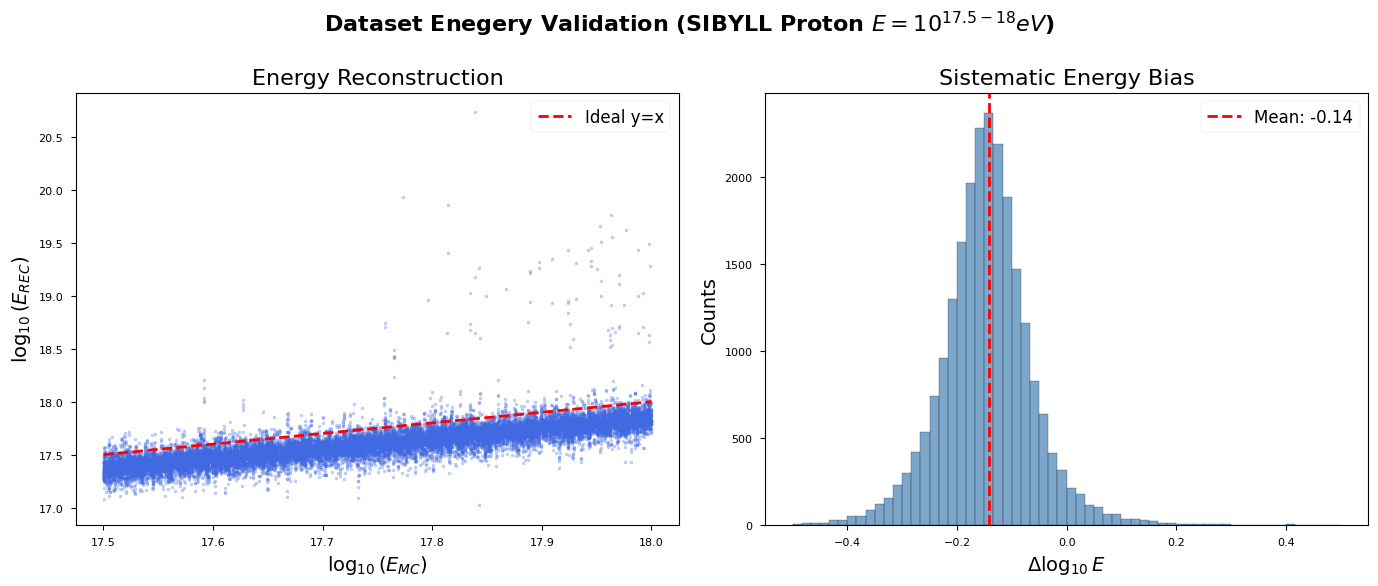

In [28]:
events_guia = df_guia[['event_id', 'logE_MC', 'logE_REC']].drop_duplicates()
deltaE = events_guia['logE_REC'] - events_guia['logE_MC']

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].scatter(events_guia['logE_MC'], events_guia['logE_REC'], s=5, alpha=0.3, color='royalblue')
axs[0].plot([17.5, 18], [17.5, 18], 'r--', label='Ideal y=x')
axs[0].set(xlabel=r'$\log_{10}(E_{MC})$', ylabel=r'$\log_{10}(E_{REC})$', title='Energy Reconstruction')
axs[0].legend()

axs[1].hist(deltaE, bins=60, range=(-0.5, 0.5), color='steelblue', edgecolor='black', alpha=0.7)
axs[1].axvline(deltaE.mean(), color='r', linestyle='--', lw=2, label=f'Mean: {deltaE.mean():.2f}')
axs[1].set(xlabel=r'$\Delta \log_{10}E$', title='Sistematic Energy Bias')
axs[1].set(ylabel='Counts')
axs[1].legend()

plt.suptitle(r"Dataset Enegery Validation (SIBYLL Proton $E = 10^{17.5-18}eV$)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

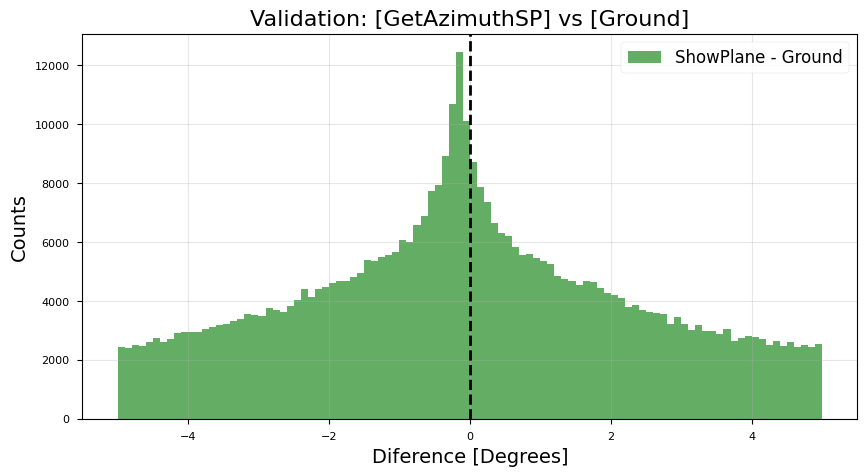

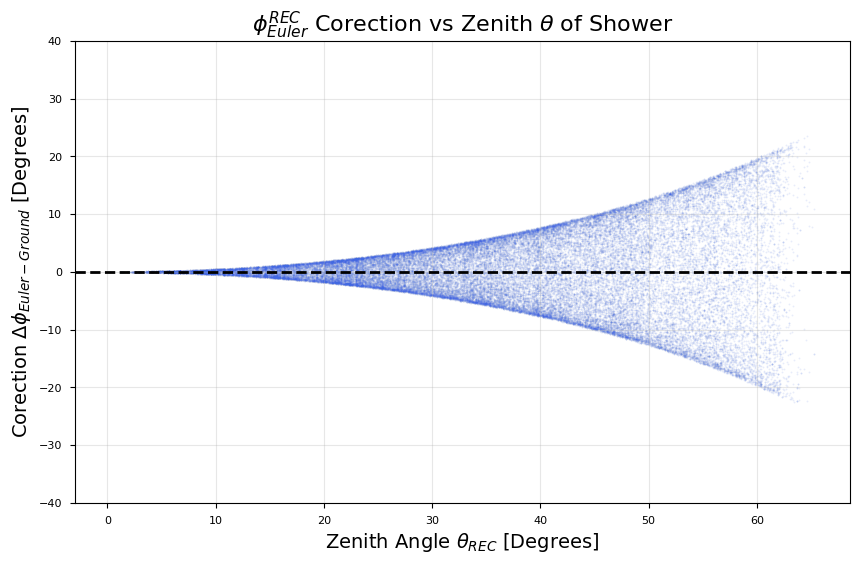

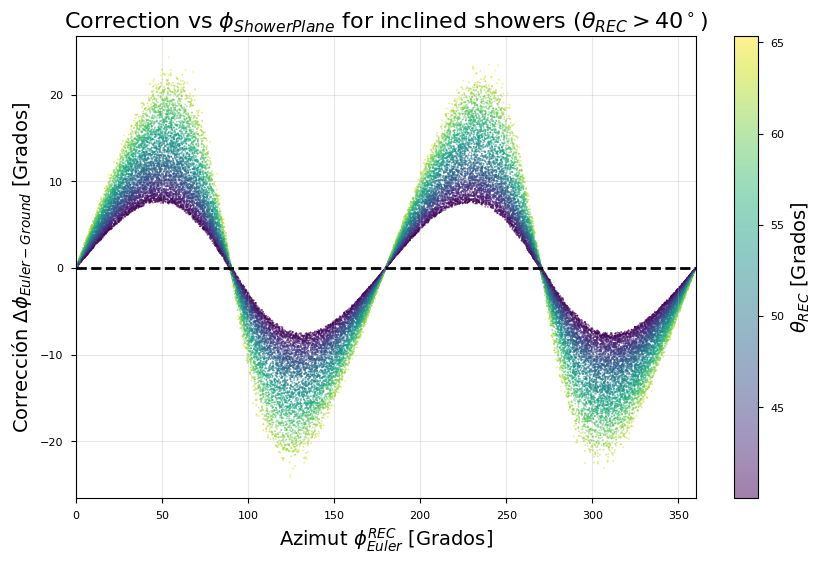

In [36]:
# =========================================================================
# CELDA 2: VALIDACIÓN GEOMÉTRICA (INFILL)
# =========================================================================
# df_new debe ser tu dataset filtrado (ej. df_master filtrado por SIB 17.5 Proton)
df_new = df_master[(df_master['Model'] == 'SIBYLL') & (df_master['Primary'] == 'Proton') & (df_master['Energy'] == '17.5-18.0')].copy()

df_infill = df_new[df_new['counterId'] >= 100000].copy()

if len(df_infill) > 0:
    vals_sp = ensure_degrees(df_infill['phi_plane_sp'], 'SP')
    vals_ground = ensure_degrees(df_infill['phi_plane_ground'], 'Ground')
    vals_euler = ensure_degrees(df_infill['phi_plane_euler'], 'Euler')
    vals_rec_phi = ensure_degrees(df_infill['phi_REC'], 'PhiRec')
    vals_theta_rec = ensure_degrees(df_infill['theta_REC'], 'ThetaRec')

    vals_sp_fixed = (vals_sp + vals_rec_phi) % 360
    vals_euler_fixed = (vals_euler + 180) % 360
    diff_offline_ground = ang_diff(vals_sp_fixed, vals_ground)
    diff_euler_ground = ang_diff(vals_euler_fixed, vals_ground)
    
    # Plot 1: Histograma
    fig_geo1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.hist(diff_offline_ground, bins=100, range=(-5, 5), color='forestgreen', alpha=0.7, label='ShowPlane - Ground')
    ax1.axvline(0, color='k', linestyle='--')
    ax1.set_title("Validation: [GetAzimuthSP] vs [Ground]")
    ax1.set_xlabel("Diference [Degrees]")
    ax1.set_ylabel("Counts")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.show()
    
    # Plot 2: Mariposa REC
    fig_geo2, ax2 = plt.subplots(figsize=(10, 6))
    n_sample = min(50000, len(df_infill))
    idx = np.random.choice(df_infill.index, n_sample, replace=False)
    sc = ax2.scatter(vals_theta_rec.loc[idx], diff_euler_ground.loc[idx], s=1, c='royalblue', alpha=0.1) 
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_title(r"$\phi_{Euler}^{REC}$ Corection vs Zenith $\theta$ of Shower")
    ax2.set_xlabel(r"Zenith Angle $\theta_{REC}$ [Degrees]")
    ax2.set_ylabel(r"Corection $\Delta\phi_{Euler-Ground}$ [Degrees]")
    ax2.set_ylim(-40, 40)
    ax2.grid(True, alpha=0.3)
    plt.show()

    # Plot 3: Serpiente REC (Theta > 40)
    mask_inclined = vals_theta_rec > 40
    if mask_inclined.sum() > 500:
        idx_snake = np.random.choice(df_infill[mask_inclined].index, min(50000, mask_inclined.sum()), replace=False)
        fig_snake, ax_snake = plt.subplots(figsize=(10, 6))
        sc_snake = ax_snake.scatter(
            vals_euler_fixed.loc[idx_snake], 
            diff_euler_ground.loc[idx_snake], 
            c=vals_theta_rec.loc[idx_snake], 
            cmap='viridis', s=1, alpha=0.5
        )
        ax_snake.axhline(0, color='k', linestyle='--')
        ax_snake.set_title(r"Correction vs $\phi_{ShowerPlane}$ for inclined showers ($\theta_{REC} > 40^\circ$)")
        ax_snake.set_xlabel(r"Azimuth $\phi_{Euler}^{REC}$ [Grados]")
        ax_snake.set_ylabel(r"Zenith Angle $\theta_{REC}$ [Degrees]")
        cbar = plt.colorbar(sc_snake, ax=ax_snake)
        cbar.set_label(r"$\theta_{REC}$ [Grados]")
        ax_snake.set_xlim(0, 360)
        ax_snake.grid(True, alpha=0.3)
        plt.show()
else:
    print("No se encontraron datos de Infill.")

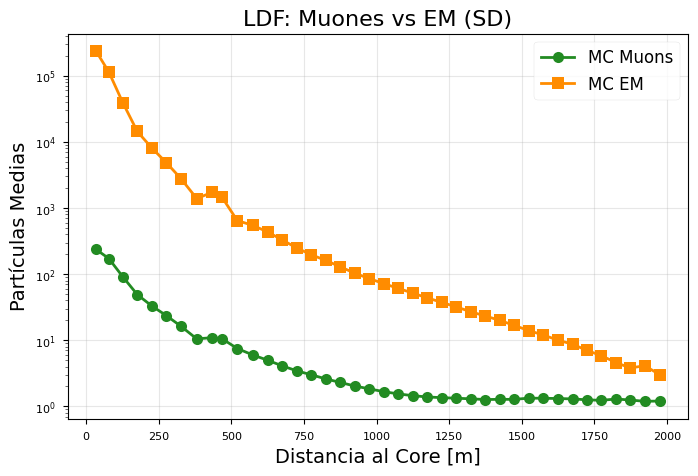

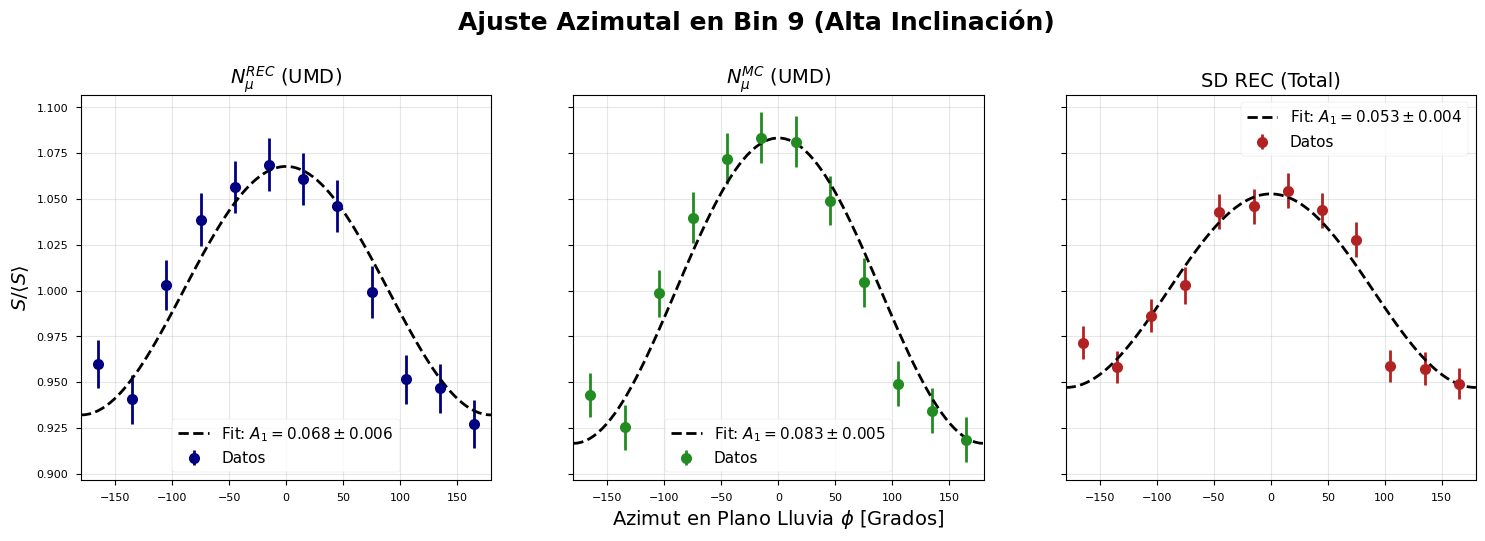

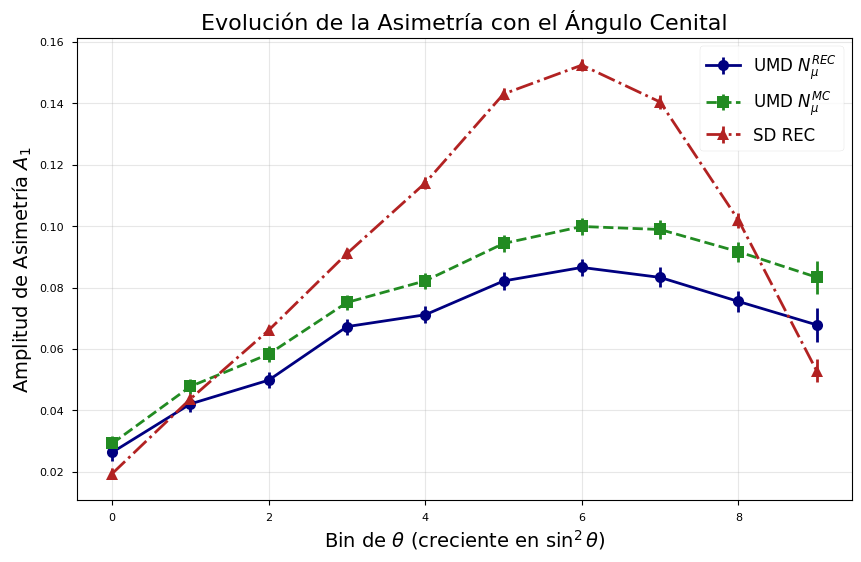

In [13]:
# =========================================================================
# CELDA 3: TIRA DE AJUSTES (sharey=True) Y EVOLUCIÓN
# =========================================================================
# LDF (Plot 7 de tu reporte original)
r_bins = np.linspace(0, 2000, 41)
df_guia['r_bin'] = pd.cut(df_guia['r_core'], bins=r_bins)
comp_stats = df_guia.groupby('r_bin', observed=True)[['r_core', 'sd_nMuons_MC', 'sd_nEM_MC']].mean().dropna()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(comp_stats['r_core'], comp_stats['sd_nMuons_MC'], 'o-', color='forestgreen', label='MC Muons')
ax1.plot(comp_stats['r_core'], comp_stats['sd_nEM_MC'], 's-', color='darkorange', label='MC EM')
ax1.set(xlabel="Distancia al Core [m]", ylabel="Partículas Medias", yscale='log', title="LDF: Muones vs EM (SD)")
ax1.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Preparación de bines
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)
df_new['theta_bin_idx'] = pd.cut(df_new['theta_REC'], bins=np.rad2deg(np.arcsin(np.sqrt(s2_bins))), labels=False)
df_ana = df_new[(df_new['counterId'] >= 90000) & (df_new['counterId'] < 100000)].copy()

df_ana['phi_deg_centered'] = (np.rad2deg(df_ana['phi_plane_sp']) + 180) % 360 - 180
phi_bin_edges = np.linspace(-180, 180, 13)
phi_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2

evol_theta, evol_a1_umd_rec, evol_err_umd_rec = [], [], []
evol_a1_umd_mc, evol_err_umd_mc, evol_a1_sd, evol_err_sd = [], [], [], []

for i in range(10):
    mask_bin = (df_ana['theta_bin_idx'] == i)
    df_sl = df_ana[mask_bin].copy()
    if len(df_sl) < 50: continue
    
    df_sl['phi_bin'] = pd.cut(df_sl['phi_deg_centered'], bins=phi_bin_edges)
    stats = df_sl.groupby('phi_bin', observed=True)[['nMuones_REC', 'nMuones_MC', 'sdSignal_REC']].agg(['mean', 'sem', 'count'])
    
    # Solo plotear para un bin específico como ejemplo para la charla (ej. el bin 8)
    plot_this_bin = (i == 9) 
    if plot_this_bin:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True) # <-- ESENCIAL: sharey=True
        fig.suptitle(f"Ajuste Azimutal en Bin {i} (Alta Inclinación)", fontsize=18, fontweight='bold', y=1.05)
        
    a1_vals, err_vals = {}, {}
    configs = [
        ('nMuones_REC', r'$N_\mu^{REC}$ (UMD)', 'navy'), 
        ('nMuones_MC', r'$N_\mu^{MC}$ (UMD)', 'forestgreen'), 
        ('sdSignal_REC', 'SD REC (Total)', 'firebrick')
    ]

    for ax_idx, (col, label, color) in enumerate(configs):
        if col not in stats.columns: continue
        means = stats[col]['mean']
        norm = means.mean()
        if pd.isna(norm) or norm == 0: continue
        y = means / norm
        yerr = (stats[col]['sem'] / norm)
        
        try:
            popt, pcov = curve_fit(fit_func_deg, phi_centers, y, p0=[0.05], sigma=yerr, absolute_sigma=True)
            A1, A1_err = popt[0], np.sqrt(pcov[0,0])
            a1_vals[col], err_vals[col] = A1, A1_err
            
            if plot_this_bin:
                ax = axs[ax_idx]
                ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color=color, label='Datos', capsize=3)
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, fit_func_deg(x_fit, A1), 'k--', label=rf'Fit: $A_1 = {A1:.3f} \pm {A1_err:.3f}$')
                ax.set_title(label, fontsize=14)
                ax.set_xlim(-180, 180)
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=11)
                if ax_idx == 0: ax.set_ylabel(r"$S / \langle S \rangle$", fontsize=14)
                if ax_idx == 1: ax.set_xlabel(r"Azimut en Plano Lluvia $\phi$ [Grados]", fontsize=14)
        except: pass
        
    if plot_this_bin: plt.show()
    
    # Guardar para evolución
    evol_theta.append(i)
    evol_a1_umd_rec.append(a1_vals.get('nMuones_REC', np.nan))
    evol_err_umd_rec.append(err_vals.get('nMuones_REC', 0))
    evol_a1_umd_mc.append(a1_vals.get('nMuones_MC', np.nan))
    evol_err_umd_mc.append(err_vals.get('nMuones_MC', 0))
    evol_a1_sd.append(a1_vals.get('sdSignal_REC', np.nan))
    evol_err_sd.append(err_vals.get('sdSignal_REC', 0))

# PLOT DE EVOLUCIÓN
fig_ev, ax_ev = plt.subplots(figsize=(10, 6))
ax_ev.errorbar(evol_theta, evol_a1_umd_rec, yerr=evol_err_umd_rec, fmt='o-', color='navy', label=r'UMD $N_\mu^{REC}$')
ax_ev.errorbar(evol_theta, evol_a1_umd_mc, yerr=evol_err_umd_mc, fmt='s--', color='forestgreen', label=r'UMD $N_\mu^{MC}$')
ax_ev.errorbar(evol_theta, evol_a1_sd, yerr=evol_err_sd, fmt='^-.', color='firebrick', label='SD REC')
ax_ev.set_xlabel(r"Bin de $\theta$ (creciente en $\sin^2\theta$)")
ax_ev.set_ylabel(r"Amplitud de Asimetría $A_1$")
ax_ev.set_title("Evolución de la Asimetría con el Ángulo Cenital")
ax_ev.legend()
ax_ev.grid(True, alpha=0.3)
plt.show()

Datos globales cargados: 60 puntos.


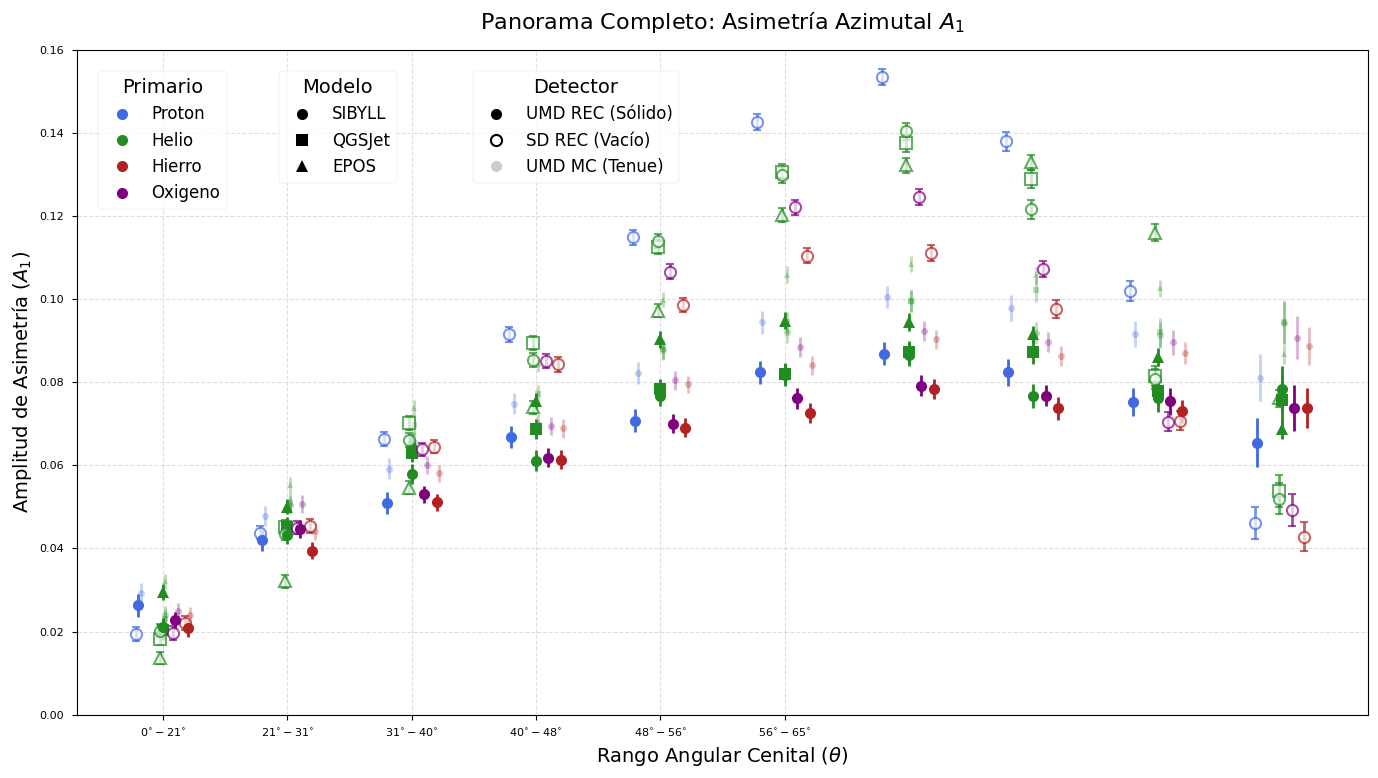

In [14]:
# =========================================================================
# CELDA 5: PLOT GLOBAL CONSOLIDADO (Tu código)
# =========================================================================
try:
    df = pd.read_csv("datos_consolidado_global.csv")
    
    # Estandarizar nombres
    rename_map = {
        'A1_UMD': 'A1_UMD_REC', 'Err_UMD': 'Err_UMD_REC',
        'A1_MC':  'A1_UMD_MC',  'Err_MC':  'Err_UMD_MC', 
        'A1_SD':  'A1_SD_REC',  'Err_SD':  'Err_SD_REC'
    }
    df.rename(columns=rename_map, inplace=True)
    if 'Theta_Bin_Idx' not in df.columns:
        df['Theta_Bin_Idx'] = df.groupby(['Primary', 'Model', 'Energy']).cumcount()
    print(f"Datos globales cargados: {len(df)} puntos.")

except FileNotFoundError:
    print("No se encontró 'datos_consolidado_global.csv'. Usando 'df_res' generado en memoria...")
    df = df_res # Asume que tenés un df_res generado de los parquets con estas columnas

theta_labels = [r"$0^{\circ}-21^{\circ}$", r"$21^{\circ}-31^{\circ}$", r"$31^{\circ}-40^{\circ}$", 
                r"$40^{\circ}-48^{\circ}$", r"$48^{\circ}-56^{\circ}$", r"$56^{\circ}-65^{\circ}$"]

colors_g = {'Proton': 'royalblue', 'Helio': 'forestgreen', 'Hierro': 'firebrick', 'Oxigeno': 'purple', 'Oxígeno': 'purple'}
model_markers = {'SIBYLL': 'o', 'QGSJet': 's', 'EPOS': '^'}

fig, ax = plt.subplots(figsize=(14, 8))
groups = df.groupby(['Primary', 'Model', 'Energy'])

# Shifts
prim_shift = {'Proton': -0.2, 'Helio': 0.0, 'Oxigeno': 0.1, 'Hierro': 0.2}
det_shift  = {'UMD_REC': 0.0, 'UMD_MC': 0.02, 'SD_REC': -0.02}

for (prim, mod, en), group in groups:
    group = group.sort_values('Theta_Bin_Idx')
    x_base = group['Theta_Bin_Idx'].values
    c = colors_g.get(prim, 'gray')
    m = model_markers.get(mod, 'o')
    x_prim = x_base + prim_shift.get(prim, 0)
    
    # 1. UMD MC (Tenue)
    if 'A1_UMD_MC' in group.columns:
        ax.errorbar(x_prim + det_shift['UMD_MC'], group['A1_UMD_MC'], yerr=group['Err_UMD_MC'], 
                    fmt=m, color=c, alpha=0.3, markersize=5, label='_nolegend_')

    # 2. SD REC (Vacío)
    if 'A1_SD_REC' in group.columns:
        ax.errorbar(x_prim + det_shift['SD_REC'], group['A1_SD_REC'], yerr=group['Err_SD_REC'], 
                    fmt=m, color=c, mfc='white', mec=c, mew=1.5, alpha=0.7, label='_nolegend_')

    # 3. UMD REC (Sólido)
    ax.errorbar(x_prim + det_shift['UMD_REC'], group['A1_UMD_REC'], yerr=group['Err_UMD_REC'], 
                fmt=m, color=c, mfc=c, alpha=1.0, label='_nolegend_')

ax.set_title(r"Panorama Completo: Asimetría Azimutal $A_1$", pad=15)
ax.set_ylabel(r"Amplitud de Asimetría ($A_1$)") # <-- Corregido
ax.set_xlabel(r"Rango Angular Cenital ($\theta$)")
ax.set_xticks(range(len(theta_labels)))
ax.set_xticklabels(theta_labels)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_ylim(0, 0.16)

# Leyendas
leg_prim = [Line2D([0],[0], color=v, marker='o', lw=0, label=k) for k,v in colors_g.items() if k != 'Oxígeno']
l1 = plt.legend(handles=leg_prim, title="Primario", loc='upper left', bbox_to_anchor=(0.01, 0.98))
ax.add_artist(l1)

leg_mod = [Line2D([0],[0], color='k', marker=v, lw=0, label=k) for k,v in model_markers.items()]
l2 = plt.legend(handles=leg_mod, title="Modelo", loc='upper left', bbox_to_anchor=(0.15, 0.98))
ax.add_artist(l2)

leg_det = [
    Line2D([0],[0], color='k', marker='o', mfc='k', lw=0, label='UMD REC (Sólido)'),
    Line2D([0],[0], color='k', marker='o', mfc='white', mec='k', mew=1.5, lw=0, label='SD REC (Vacío)'),
    Line2D([0],[0], color='gray', marker='o', alpha=0.4, lw=0, label='UMD MC (Tenue)')
]
plt.legend(handles=leg_det, title="Detector", loc='upper left', bbox_to_anchor=(0.30, 0.98))

plt.tight_layout()
plt.show()

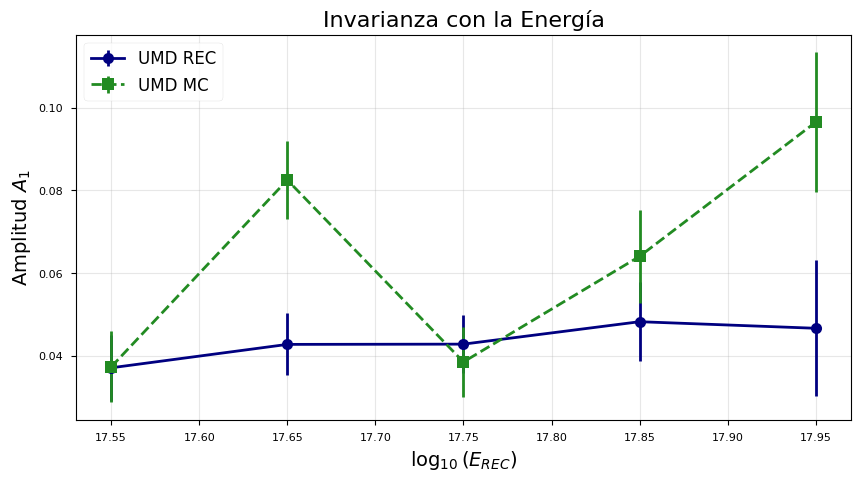

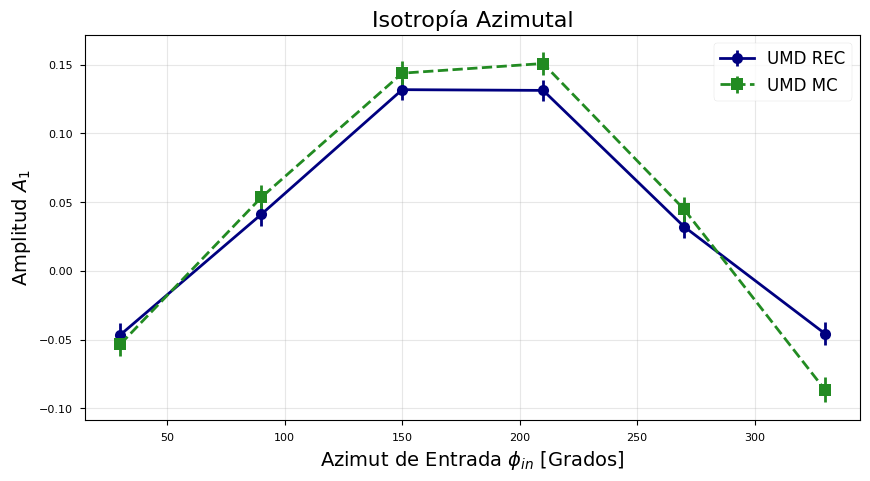

In [7]:
# =========================================================================
# CELDA 4: ESTUDIOS SISTEMÁTICOS (ENERGÍA E ISOTROPÍA)
# =========================================================================
theta_min_inv, theta_max_inv = 30, 50
mask_sys = (df_new['theta_REC'] >= theta_min_inv) & (df_new['theta_REC'] < theta_max_inv) & (df_new['counterId'] >= 90000)
df_sys = df_new[mask_sys].copy()

# Preparar datos
phi_e_rec = np.rad2deg(df_sys['phi_plane_sp'])
df_sys['phi_rec_cen'] = (phi_e_rec + 180) % 360 - 180
df_sys['phi_mc_cen'] = df_sys['phi_rec_cen'] # Aproximación si no tenés SP_MC
phi_fit_centers = (np.linspace(-180, 180, 13)[:-1] + np.linspace(-180, 180, 13)[1:]) / 2

e_bins = np.linspace(17.5, 18.0, 6)
e_cents = (e_bins[:-1] + e_bins[1:]) / 2
res_en = {'rec': [], 'rec_err': [], 'mc': [], 'mc_err': []}

for i in range(len(e_bins)-1):
    df_b = df_sys[(df_sys['logE_REC'] >= e_bins[i]) & (df_sys['logE_REC'] < e_bins[i+1])]
    
    # REC
    stats_r = df_b.groupby(pd.cut(df_b['phi_rec_cen'], 12), observed=True)['nMuones_REC'].agg(['mean','sem']).dropna()
    nr = stats_r['mean'].mean()
    try: 
        popt, pcov = curve_fit(fit_func_deg, phi_fit_centers, stats_r['mean']/nr, p0=[0.05], sigma=stats_r['sem']/nr, absolute_sigma=True)
        res_en['rec'].append(popt[0]); res_en['rec_err'].append(np.sqrt(pcov[0,0]))
    except: res_en['rec'].append(np.nan); res_en['rec_err'].append(np.nan)
    
    # MC
    stats_m = df_b.groupby(pd.cut(df_b['phi_mc_cen'], 12), observed=True)['nMuones_MC'].agg(['mean','sem']).dropna()
    nm = stats_m['mean'].mean()
    try:
        popt, pcov = curve_fit(fit_func_deg, phi_fit_centers, stats_m['mean']/nm, p0=[0.05], sigma=stats_m['sem']/nm, absolute_sigma=True)
        res_en['mc'].append(popt[0]); res_en['mc_err'].append(np.sqrt(pcov[0,0]))
    except: res_en['mc'].append(np.nan); res_en['mc_err'].append(np.nan)

fig_e, ax_e = plt.subplots(figsize=(10, 5))
ax_e.errorbar(e_cents, res_en['rec'], yerr=res_en['rec_err'], fmt='o-', label='UMD REC', color='navy')
ax_e.errorbar(e_cents, res_en['mc'], yerr=res_en['mc_err'], fmt='s--', label='UMD MC', color='forestgreen')
ax_e.set_xlabel(r"$\log_{10}(E_{REC})$")
ax_e.set_ylabel(r"Amplitud $A_1$")
ax_e.set_title("Invarianza con la Energía")
ax_e.legend(); ax_e.grid(True, alpha=0.3)
plt.show()

# 8.2 Isotropía
phi_in_edges = np.linspace(0, 360, 7)
phi_in_cents = (phi_in_edges[:-1] + phi_in_edges[1:]) / 2
res_iso = {'rec': [], 'rec_err': [], 'mc': [], 'mc_err': []}

df_sys['sect'] = pd.cut(df_sys['phi_REC'], bins=phi_in_edges)
for i in range(6):
    df_s = df_sys[df_sys['sect'].cat.codes == i]
    # REC
    stats_r = df_s.groupby(pd.cut(df_s['phi_rec_cen'], 12), observed=True)['nMuones_REC'].agg(['mean','sem']).dropna()
    nr = stats_r['mean'].mean()
    try:
        popt, pcov = curve_fit(fit_func_deg, phi_fit_centers, stats_r['mean']/nr, p0=[0.05], sigma=stats_r['sem']/nr, absolute_sigma=True)
        res_iso['rec'].append(popt[0]); res_iso['rec_err'].append(np.sqrt(pcov[0,0]))
    except: res_iso['rec'].append(np.nan); res_iso['rec_err'].append(np.nan)
    # MC
    stats_m = df_s.groupby(pd.cut(df_s['phi_mc_cen'], 12), observed=True)['nMuones_MC'].agg(['mean','sem']).dropna()
    nm = stats_m['mean'].mean()
    try:
        popt, pcov = curve_fit(fit_func_deg, phi_fit_centers, stats_m['mean']/nm, p0=[0.05], sigma=stats_m['sem']/nm, absolute_sigma=True)
        res_iso['mc'].append(popt[0]); res_iso['mc_err'].append(np.sqrt(pcov[0,0]))
    except: res_iso['mc'].append(np.nan); res_iso['mc_err'].append(np.nan)

fig_i, ax_i = plt.subplots(figsize=(10, 5))
ax_i.errorbar(phi_in_cents, res_iso['rec'], yerr=res_iso['rec_err'], fmt='o-', color='navy', label='UMD REC')
ax_i.errorbar(phi_in_cents, res_iso['mc'], yerr=res_iso['mc_err'], fmt='s--', color='forestgreen', label='UMD MC')
ax_i.set_xlabel(r"Azimut de Entrada $\phi_{in}$ [Grados]")
ax_i.set_ylabel(r"Amplitud $A_1$")
ax_i.set_title("Isotropía Azimutal")
ax_i.legend(); ax_i.grid(True, alpha=0.3)
plt.show()

In [9]:
# =========================================================================
# CELDA 6: MONEY PLOTS (Discriminación de Masa)
# =========================================================================
# Asumo que tenés un DataFrame resumen "df_res" que incluye la fila "Mix"
# Si usas el CSV, ajustá esto para leer del CSV.
money_data = df_res[(df_res['Model'] == 'SIBYLL') & (df_res['Energy'] == '17.5-18.0')]

# 1. Evolución P vs Fe con Eje MF (Sin Shifts, Sin Línea en el MF)
fig, ax1 = plt.subplots(figsize=(10, 6))

for prim in ['Proton', 'Hierro']:
    g = money_data[money_data['Primary'] == prim].sort_values('ThetaBin')
    ax1.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], fmt='o-', color=COLORS[prim], label=prim, lw=2, capsize=4)

p_data = money_data[money_data['Primary'] == 'Proton'].set_index('ThetaBin')
fe_data = money_data[money_data['Primary'] == 'Hierro'].set_index('ThetaBin')
common = p_data.index.intersection(fe_data.index)

mf_vals = [calc_mf(p_data.loc[b, 'A1'], p_data.loc[b, 'Err'], fe_data.loc[b, 'A1'], fe_data.loc[b, 'Err']) for b in common]

ax2 = ax1.twinx()
# "kX" hace que sean solo las cruces negras, sin línea que las una
ax2.plot(common, mf_vals, 'kX', markersize=9, label='MF (P vs Fe)')

ax1.set_xlabel('Bin de Theta')
ax1.set_ylabel(r'Amplitud de Asimetría $A_1$')
ax1.set_title('Sensibilidad a la Masa (SIBYLL 17.5-18.0)')
ax2.set_ylabel(r'Merit Factor ($\sigma$)', color='black', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.show()

# 2. El BIN de MÁXIMO MF con el MIX (Usando el plot de Gaussianas)
max_bin = common[np.argmax(mf_vals)]

mus, sigs, labs, cols = [], [], [], []
proton_stats, iron_stats = None, None

for p in ['Proton', 'Mix', 'Hierro']:
    r = money_data[(money_data['Primary'] == p) & (money_data['ThetaBin'] == max_bin)]
    if not r.empty:
        m, s = r['A1'].values[0], r['Err'].values[0]
        mus.append(m); sigs.append(s); labs.append(p); cols.append(COLORS.get(p))
        if p == 'Proton': proton_stats = (m, s)
        if p == 'Hierro': iron_stats = (m, s)

if len(mus) >= 2:
    fig_g, ax_g = plt.subplots(figsize=(10, 6))
    plot_annotated_gaussians(ax_g, mus, sigs, labs, cols, f"Discriminación de Masa (Bin {max_bin})")
    
    mf_p_fe = calc_mf(proton_stats[0], proton_stats[1], iron_stats[0], iron_stats[1])
    ax_g2 = ax_g.twinx()
    ax_g2.set_ylim(0, max(4.0, mf_p_fe + 1.0))
    ax_g2.set_ylabel(r"Separación MF ($\sigma$)", color='navy')
    ax_g2.axhline(mf_p_fe, color='navy', linestyle='--', linewidth=1.5, alpha=0.7)
    ax_g2.text(ax_g.get_xlim()[1], mf_p_fe + 0.1, rf" MF: {mf_p_fe:.2f}$\sigma$", 
               ha='right', va='bottom', color='navy', fontweight='bold')
    plt.show()

NameError: name 'df_res' is not defined

In [15]:
money_data = df_res[(df_res['Model'] == 'SIBYLL') & (df_res['Energy'] == '17.5-18.0')]

# 1. Evolución P vs Fe con Eje MF
fig, ax1 = plt.subplots(figsize=(10, 6))
shifts = {'Proton': -0.1, 'Hierro': 0.1}

for prim in ['Proton', 'Hierro']:
    g = money_data[money_data['Primary'] == prim].sort_values('ThetaBin')
    ax1.errorbar(g['ThetaBin'] + shifts[prim], g['A1'], yerr=g['Err'], fmt='o-', color=COLORS[prim], label=prim, lw=2, capsize=4)

p_data = money_data[money_data['Primary'] == 'Proton'].set_index('ThetaBin')
fe_data = money_data[money_data['Primary'] == 'Hierro'].set_index('ThetaBin')
common = p_data.index.intersection(fe_data.index)

mf_vals = [calc_mf(p_data.loc[b, 'A1'], p_data.loc[b, 'Err'], fe_data.loc[b, 'A1'], fe_data.loc[b, 'Err']) for b in common]

ax2 = ax1.twinx()
ax2.plot(common, mf_vals, 'k:', marker='X', markersize=8, label='MF (P vs Fe)')
ax1.set(xlabel='Bin de Theta', ylabel='Amplitud $A_1$', title='Sensibilidad a la Masa (SIBYLL 17.5)')
ax2.set_ylabel('Merit Factor ($\sigma$)', color='black', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left'); ax1.grid(alpha=0.3)
plt.show()

# 2. El BIN de MÁXIMO MF con el MIX
max_bin = common[np.argmax(mf_vals)]
bin_data = money_data[money_data['ThetaBin'] == max_bin]

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = [1, 2, 3]
prims = ['Proton', 'Mix', 'Hierro']
vals = [bin_data[bin_data['Primary'] == p]['A1'].values[0] for p in prims]
errs = [bin_data[bin_data['Primary'] == p]['Err'].values[0] for p in prims]

for x, p, v, e in zip(x_pos, prims, vals, errs):
    ax.errorbar(x, v, yerr=e, fmt='o', color=COLORS[p], markersize=10, capsize=6, lw=2)
    
ax.set_xticks(x_pos); ax.set_xticklabels(prims, fontsize=14, fontweight='bold')
ax.set(ylabel='Amplitud $A_1$', title=f'Separación en el Bin de Máximo MF (Bin {max_bin})')
ax.grid(axis='y', alpha=0.3)
plt.show()

NameError: name 'df_res' is not defined

In [10]:
# =========================================================================
# CELDA 7: INCERTIDUMBRE HADRÓNICA CON MF
# =========================================================================
# SIBYLL vs QGSJet para Helio 17.5-18.0
he_data = df_res[(df_res['Primary'] == 'Helio') & (df_res['Energy'] == '17.5-18.0') & (df_res['Model'].isin(['SIBYLL', 'QGSJet']))]

fig, ax1 = plt.subplots(figsize=(10, 6))
colors_mod = {'SIBYLL': 'forestgreen', 'QGSJet': 'darkorange'}

for mod in ['SIBYLL', 'QGSJet']:
    g = he_data[he_data['Model'] == mod].sort_values('ThetaBin')
    ax1.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], fmt=MARKERS[mod]+LINES[mod], 
                 color=colors_mod[mod], label=mod, alpha=0.9, capsize=4)

# Calcular MF entre modelos
sib_data = he_data[he_data['Model'] == 'SIBYLL'].set_index('ThetaBin')
qgs_data = he_data[he_data['Model'] == 'QGSJet'].set_index('ThetaBin')
common_mods = sib_data.index.intersection(qgs_data.index)

mf_mods = [calc_mf(sib_data.loc[b, 'A1'], sib_data.loc[b, 'Err'], qgs_data.loc[b, 'A1'], qgs_data.loc[b, 'Err']) for b in common_mods]

ax2 = ax1.twinx()
ax2.plot(common_mods, mf_mods, 'kX', markersize=9, label='MF (SIB vs QGS)')

ax1.set_xlabel('Bin de Theta')
ax1.set_ylabel(r'Amplitud de Asimetría $A_1$')
ax1.set_title('Incertidumbre Hadrónica: Helio 17.5')
ax2.set_ylabel(r'Diferencia MF ($\sigma$)', color='black', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.show()

NameError: name 'df_res' is not defined

In [16]:
# SIBYLL vs QGSJet para Helio 17.5-18.0
he_data = df_res[(df_res['Primary'] == 'Helio') & (df_res['Energy'] == '17.5-18.0') & (df_res['Model'].isin(['SIBYLL', 'QGSJet']))]

fig, ax = plt.subplots(figsize=(10, 6))
for mod in ['SIBYLL', 'QGSJet']:
    g = he_data[he_data['Model'] == mod].sort_values('ThetaBin')
    ax.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], fmt=MARKERS[mod]+LINES[mod], color='forestgreen', label=mod, alpha=0.8, capsize=4)

ax.set(xlabel='Bin de Theta', ylabel='Amplitud $A_1$', title='Incertidumbre Hadrónica: Helio 17.5')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

NameError: name 'df_res' is not defined